In [ ]:
# Fake_news_detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk

In [ ]:
df=pd.read_csv("train(1).csv")

In [ ]:
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
df["title"][0]

'House Dem Aide: We Didn’t Even See Comey’s Letter Until Jason Chaffetz Tweeted It'

In [ ]:
df["text"][0]

'House Dem Aide: We Didn’t Even See Comey’s Letter Until Jason Chaffetz Tweeted It By Darrell Lucus on October 30, 2016 Subscribe Jason Chaffetz on the stump in American Fork, Utah ( image courtesy Michael Jolley, available under a Creative Commons-BY license) \nWith apologies to Keith Olbermann, there is no doubt who the Worst Person in The World is this week–FBI Director James Comey. But according to a House Democratic aide, it looks like we also know who the second-worst person is as well. It turns out that when Comey sent his now-infamous letter announcing that the FBI was looking into emails that may be related to Hillary Clinton’s email server, the ranking Democrats on the relevant committees didn’t hear about it from Comey. They found out via a tweet from one of the Republican committee chairmen. \nAs we now know, Comey notified the Republican chairmen and Democratic ranking members of the House Intelligence, Judiciary, and Oversight committees that his agency was reviewing emai

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20800 non-null  int64 
 1   title   20242 non-null  object
 2   author  18843 non-null  object
 3   text    20761 non-null  object
 4   label   20800 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 812.6+ KB


In [ ]:
df=df.drop(columns=["id","title","author"],axis=1)

In [ ]:
df=df.dropna(axis=0)

In [ ]:
len(df)

20761

In [ ]:
df["clean_news"]=df["text"].str.lower()
df["clean_news"]

,clean_news
0,house dem aide: we didn’t even see comey’s let...
1,ever get the feeling your life circles the rou...
2,"why the truth might get you fired october 29, ..."
3,videos 15 civilians killed in single us airstr...
4,print \nan iranian woman has been sentenced to...
...,...
20795,rapper t. i. unloaded on black celebrities who...
20796,when the green bay packers lost to the washing...
20797,the macy’s of today grew from the union of sev...
20798,"nato, russia to hold parallel exercises in bal..."


In [ ]:
df['clean_news']=df['clean_news'].str.replace('[^A-Za-z0-9\s]' , '')
df['clean_news']=df['clean_news'].str.replace('\n' , '')
df['clean_news']=df['clean_news'].str.replace('\s+' , ' ')
df['clean_news']

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1403/372290457.py:1: SyntaxWarning: invalid escape sequence '\s'
  df['clean_news']=df['clean_news'].str.replace('[^A-Za-z0-9\s]' , '')
/tmp/ipykernel_1403/372290457.py:3: SyntaxWarning: invalid escape sequence '\s'
  df['clean_news']=df['clean_news'].str.replace('\s+' , ' ')


,clean_news
0,house dem aide: we didn’t even see comey’s let...
1,ever get the feeling your life circles the rou...
2,"why the truth might get you fired october 29, ..."
3,videos 15 civilians killed in single us airstr...
4,print an iranian woman has been sentenced to s...
...,...
20795,rapper t. i. unloaded on black celebrities who...
20796,when the green bay packers lost to the washing...
20797,the macy’s of today grew from the union of sev...
20798,"nato, russia to hold parallel exercises in bal..."


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop=stopwords.words('english')
df['clean_news'] = df['clean_news'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


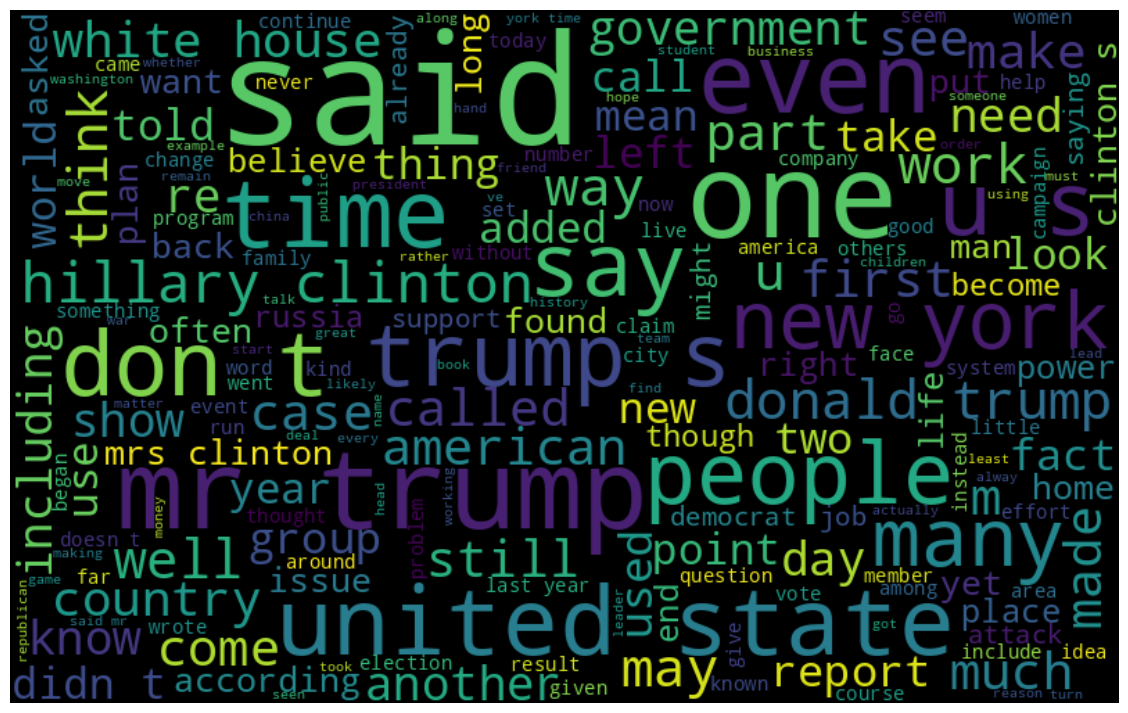

In [ ]:
# visualises the frequent words
all_words = " ".join([sentrence for sentrence in df["clean_news"]])
wordcloud = WordCloud(width=800,height=500,random_state=42,max_font_size=110).generate(all_words)

# plot the graph
plt.figure(figsize=(15,9))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# tokenize text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df["clean_news"])
word_index = tokenizer.word_index
vocab_size = len(word_index)
vocab_size

239490

In [ ]:
# padding data
sequences = tokenizer.texts_to_sequences(df["clean_news"])
padded_seq = pad_sequences(sequences,maxlen=250,padding='post',truncating='post')
padded_seq

array([[   47,  5757,  2238, ...,  3043,  7511,  2864],
       [  263,    33,  1664, ...,   968,  2144, 20017],
       [  648,   121,    33, ...,  2400,    28,   515],
       ...,
       [10013,   224,  1559, ...,  1423,   447,   315],
       [  982,    89,   781, ...,     0,     0,     0],
       [  651, 17619,   815, ...,  7722,   970,   535]], dtype=int32)

In [ ]:
# create embedding index
embadding_index = {}
with open('archive.zip',encoding='utf-8') as f:
   for line in f:
     values= line.split()
     word = values[0]
     coefs = np.asarray(values[1:],dtype='float32')
     embadding_index[word] = coefs

An unexpected error occurred: File is not a zip file
Loaded 0 word vectors.


In [ ]:
# create embding matrix
embedding_matrix = np.zeros((vocab_size+1, 100))
for word , i in word_index.items():
  emb_vec = embadding_index.get(word)
  if emb_vec is not None:
      embedding_matrix[i] = emb_vec

In [ ]:
embedding_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
padded_seq[1]

array([   263,     33,   1664,     98,   5160,  29141,    455,   2398,
         2133,    400,    585,   1649,   5598,     34,     13,    851,
          195,    401,   2018,  18224,    860,  21147,   3122,   2786,
          692,    794,    274,   2102,   3296,  11415,    141,     43,
         2279,  92501,   3242,   3788,   3712,   3296,    857,    174,
         3592,     34,  10156,  58231,   3369,     20,    233,     23,
         3345,  21147,  10411,    618,     12,    526,   2537,   2552,
         8367,    512,    743,   1539,    668,    157,     16,  23475,
          955,  25154,    354,     10,    178,   3833,     60,  11860,
          931,   2822,     19,    890,   5149,    190,     53,   5616,
         2279,   4667,     46,    275,    857,    224,     15,      4,
         2267,     15,      1,   2279,  10156,     67,   8819,  11577,
       125488,  21584,   3905, 125489,  92502, 125490,   5695,  33525,
        28278,   8336,  19691,  75630,   4603,      4,    176,    278,
      

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(padded_seq,df["label"],test_size=0.20,random_state=42,stratify=df['label'])

In [ ]:
# model training
from keras.layers import LSTM, Dropout, Dense, Embedding, Bidirectional
from keras.models import Sequential

In [ ]:
model = Sequential([
    Embedding(vocab_size+1,100,weights=[embedding_matrix],trainable=False),
    Dropout(0.2),
    LSTM (120),
    Dropout(0.2),
    Dense(250),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │    23,949,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,949,100 (91.36 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,949,100 (91.36 MB)

In [ ]:
# train the model

history = model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 190s 357ms/step - accuracy: 0.5007 - loss: 0.6936 - val_accuracy: 0.5004 - val_loss: 0.6932
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 165s 318ms/step - accuracy: 0.4986 - loss: 0.6933 - val_accuracy: 0.5004 - val_loss: 0.6933
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 152s 293ms/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.4996 - val_loss: 0.6932
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 145s 280ms/step - accuracy: 0.4964 - loss: 0.6932 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 5/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 141s 272ms/step - accuracy: 0.5026 - loss: 0.6933 - val_accuracy: 0.5004 - val_loss: 0.6931
Epoch 6/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - accuracy: 0.4978 - loss: 0.6932 - val_accuracy: 0.5004 - val_loss: 0.6931
Epoch 7/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 139s 269ms/step - accuracy: 0.4901 - loss: 0.6932 - val_accuracy: 0.5004 - val_loss: 0.6931
Epoch 8/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 147s 284ms/step - accuracy: 0.4986 -

In [ ]:
# visualize the results
plt.plot(history.history['accuracy'])
plt.plt(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'])
plt.show()

plt.plt(history.history['loss'])
plt.plt(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.show()